# Submission Summary

| Item | Information |
|---|---|
| Group number | 28 |
| Your full name | NULL |
| Dataset | Stroke Prediction |
| Depth track | To be determined |
| Team members | To be added |
| Final model | To be determined |
| Stratified dummy F1 / ROC AUC | To be determined |
| Final model F1 / ROC AUC | To be determined |
| Leakage columns dropped | To be determined |
| Full run time on Colab | To be determined |

In [5]:
!pip install -q kagglehub

In [36]:
import kagglehub
import pandas as pd
import os
import sqlite3

# Part 1. Data Foundation

### 1. Load the dataset from Kaggle inside the notebook and push it into a SQLite database.

In [42]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
print(path)
print(os.listdir(path))

file_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(file_path)

C:\Users\paula\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1
['healthcare-dataset-stroke-data.csv']


In [39]:
# Pushing dataset into SQLite database

conn = sqlite3.connect(":memory:")
df.to_sql("stroke_data", conn, index=False)

5110

In [41]:
# Checking the first 5 rows of the dataset using SQL query

sql_query = pd.read_sql_query("""SELECT * FROM stroke_data LIMIT 5""", conn)
print(sql_query)

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21  28.1     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


### 2. Run at least three SQL queries that reveal something useful, each followed by a markdown cellexplaining what you learned

In [43]:
pd.read_sql("""
SELECT DISTINCT smoking_status
FROM stroke_data;
""", conn)

,smoking_status
0,formerly smoked
1,never smoked
2,smokes
3,Unknown


With the above SQL query we were able to figure out the various category of patients in our dataset as relates to their smoking status.

In [45]:
pd.read_sql("""
SELECT smoking_status, COUNT(*) AS num_people
FROM stroke_data
GROUP BY smoking_status
ORDER BY num_people DESC;
""", conn)

,smoking_status,num_people
0,never smoked,1892
1,Unknown,1544
2,formerly smoked,885
3,smokes,789


With the above SQL query we were able to figure out the number of patients in the various category as relates to their smoking status.

In [46]:
pd.read_sql("""
SELECT
    SUM(heart_disease) AS total_heart_disease,
    AVG(age) AS average_age
FROM stroke_data
WHERE heart_disease = 1;
""", conn)

,total_heart_disease,average_age
0,276,68.188406


With the above SQL query we were able to figure out the median age of the patients with heart disease.

In [44]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 3. Performing EDA: shape, types, missing values, target distribution, and three to five feature distributions.

In [13]:
df.shape

(5110, 12)

In [48]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [15]:
missing_bmi = df["bmi"].isnull().sum()
missing_bmi_percentage = (missing_bmi / len(df)) * 100

print("Missing BMI:", missing_bmi)
print("Percentage missing:", missing_bmi_percentage)

Missing BMI: 201
Percentage missing: 3.9334637964774952


In [16]:
df.groupby(df["bmi"].isnull())["stroke"].mean()

bmi
False    0.042575
True     0.199005
Name: stroke, dtype: float64

In [17]:
df.groupby(df["bmi"].isnull())["age"].mean()

bmi
False    42.865374
True     52.049154
Name: age, dtype: float64

In [18]:
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [19]:
median_bmi = df["bmi"].median()
df["bmi"] = df["bmi"].fillna(median_bmi)

In [20]:
df["bmi"].isnull().sum()

np.int64(0)

In [21]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [22]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [23]:
df["stroke"].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [24]:
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

### Age Distribution:

The dataset contains individuals across a broad range of ages, from infants to 82 years old. The average age is approximately 43 years, while the median age is 45 years.

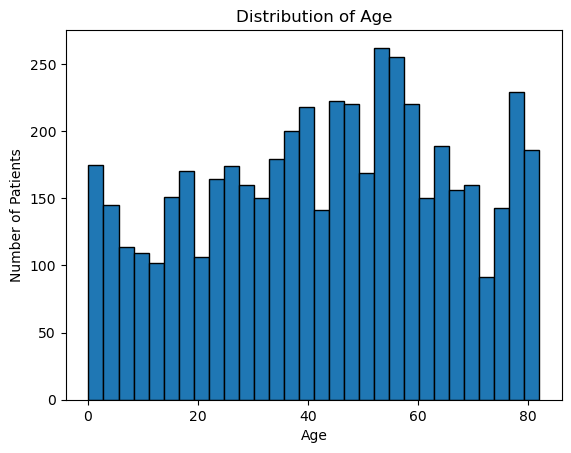

In [25]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Distribution of Age")
plt.show()

In [26]:
df["avg_glucose_level"].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

### Average Glucose Level Distribution:

The distribution is right-skewed. Most patients have lower to moderate glucose levels, while a smaller number have much higher values, which pulls the mean above the median.

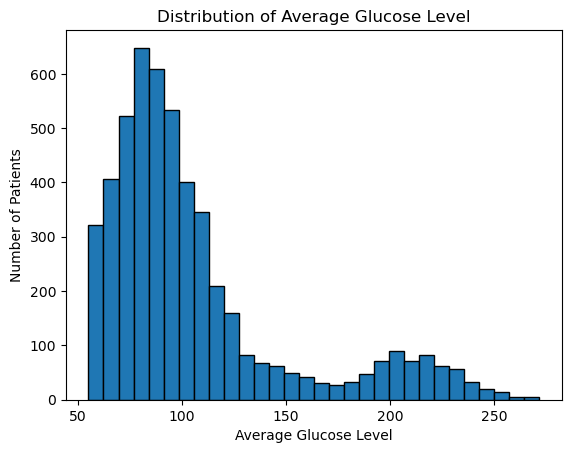

In [27]:
plt.hist(df["avg_glucose_level"], bins=30, edgecolor="black")
plt.xlabel("Average Glucose Level")
plt.ylabel("Number of Patients")
plt.title("Distribution of Average Glucose Level")
plt.show()

In [28]:
df["bmi"].describe()

count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

### BMI Distribution:

BMI is slightly right-skewed, with most observations concentrated around the mid-20s to low-30s. A few unusually high BMI values are present, including a maximum of 97.6. These values were retained because a high value alone is not sufficient evidence that the observation is incorrect.

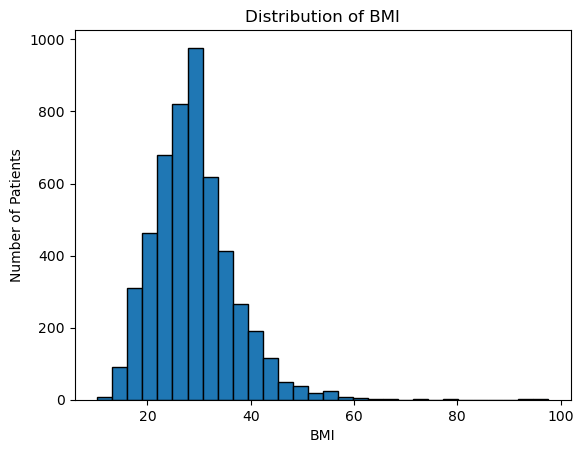

In [29]:
plt.hist(df["bmi"], bins=30, edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("Distribution of BMI")
plt.show()

In [30]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [31]:
df["smoking_status"].value_counts(normalize=True) * 100

smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64

### Smoking Status Distribution:

The largest group consists of individuals who never smoked (37.0%), followed by individuals with unknown smoking status (30.2%). Former smokers account for 17.3%, while current smokers account for 15.4%. The relatively large Unknown category should be retained as a separate category because it represents unavailable information rather than confirmed non-smoking.

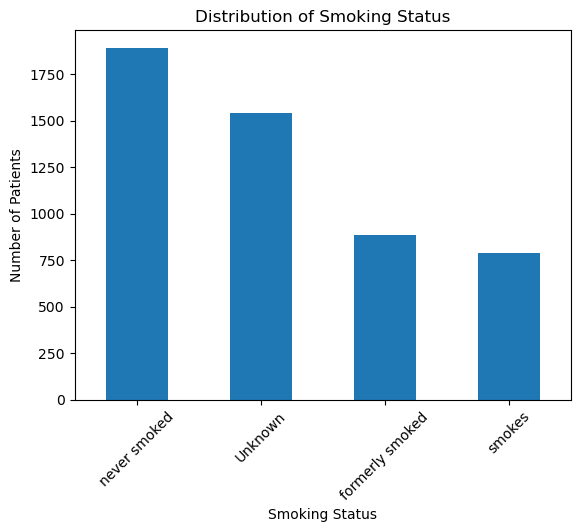

In [32]:
df["smoking_status"].value_counts().plot(kind="bar")

plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Smoking Status")
plt.xticks(rotation=45)
plt.show()

In [33]:
df["hypertension"].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

### Hypertension Distribution:

Most individuals in the dataset do not have hypertension (90.3%), while approximately 9.7% have hypertension. Although the column is stored as an integer, it represents a binary categorical variable where 0 means no hypertension and 1 means hypertension.

In [34]:
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0    90.254403
1     9.745597
Name: proportion, dtype: float64

### Duplicate Check:

No exact duplicate rows were found in the dataset, so no rows were removed for duplication.

In [35]:
df.duplicated().sum()

np.int64(0)